# 08_优化算法-Adam优化器

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 保留 Adam 理论，用 NumPy 实现一阶矩、二阶矩与偏差修正，并在线性回归上演示；原深层网络训练案例不转写。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊深度学习中非常常用的一个优化器，Adam。

Adam优化器（**Adaptive Moment Estimation**）是一种用于训练深度学习模型的梯度优化算法。

它结合了**动量法**和**RMSProp**算法的优点，能够以自适应的方式调整每个参数的学习率，从而加快模型的训练速度并提高收敛的稳定性。Adam通过维护梯度的一阶动量（平均值）和二阶动量（梯度平方的指数加权移动平均值）来动态调整学习率，使得在不同维度上能够进行更精细的学习。

直白点讲，Adam优化器可以理解为一种“聪明的调参助手”，它能帮助你的模型更高效地学习。

假设在爬一座山（优化目标），Adam相当于给你提供了两个工具：

- **记住你最近的动作方向（梯度）**：Adam会追踪你之前爬的方向，比如你连续几次向东南方向爬，那它会认为东南可能是个好方向，就会加快这个方向的步伐（动量）。
- **注意地形的变化**：Adam还会观察地形，如果你前面走的地方坡度特别陡，它会帮你小心一点，走得慢一些；而在相对平坦的地方，它会鼓励你迈大步（自适应学习率）。

这样，Adam可以帮你快速找到最优解（山顶），不用总是原地打转或者走得太快掉下去。它的“自适应”特性让每一步的调整都更为智能化，能够适应不同的地形（模型的不同参数）来进行更好的调整。

总结来说，Adam的好处就是它既能记住走的方向，又能根据当前的地形变化动态调整步伐，从而让模型的训练更加稳定和高效。

## 理论基础

Adam优化器利用梯度的一阶和二阶动量（均值和方差）来调整每个参数的学习率，确保在不同维度上学习步伐的智能化调整。

#### 1. 初始化参数

在训练开始时，我们需要初始化一些超参数以及模型的权重：

- **学习率** $\alpha$（通常默认值为 $\alpha = 0.001$）
- **一阶动量衰减因子** $\beta_1$（通常默认值为 $\beta_1 = 0.9$）
- **二阶动量衰减因子** $\beta_2$（通常默认值为 $\beta_2 = 0.999$）
- **防止除零的小常数** $\epsilon$（通常默认值为 $\epsilon = 10^{-8}$）
- 初始化参数 $\theta_0$（即模型的权重）
- 初始化一阶动量估计 $m_0 = 0$
- 初始化二阶动量估计 $v_0 = 0$

#### 2. 计算梯度

在每次迭代的步骤 $t$，我们会基于当前模型的损失函数 $L(\theta)$计算出每个参数 $\theta$的梯度：


$$
g_t = \nabla_{\theta} L(\theta_t)
$$


这个梯度 $g_t$表示了损失函数对参数的变化率，指示了参数如何更新才能最小化损失。

#### 3. 更新一阶动量估计（动量法）

一阶动量估计是梯度的指数加权移动平均（指数平滑的均值），类似于“动量”的概念。动量法的目的是让梯度在历史上的变化方向产生影响，以便能在梯度更新过程中加速。

更新公式为：


$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
$$


其中：

- $\beta_1$是动量衰减因子，控制着历史梯度的影响大小，值越接近1，表示历史梯度的影响越大。
- $m_t$是当前时刻的动量估计，表示梯度的指数加权平均。

#### 4. 更新二阶动量估计（RMSProp 部分）

二阶动量估计是梯度平方的指数加权移动平均，用来衡量梯度的方差。它类似于RMSProp算法中的梯度平方的平滑，这有助于动态调整学习率。

更新公式为：


$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$


其中：

- $\beta_2$控制二阶动量的衰减速度，值越接近1，表示对历史平方梯度的考虑越多。
- $v_t$是当前时刻的二阶动量估计，表示梯度平方的指数加权平均。

#### 5. 偏差校正

由于在动量和均方根估计的计算中采用了指数加权平均，在初期迭代时，$m_t$和 $v_t$的值会偏小，导致优化器的更新效果不准确。因此，Adam引入了偏差校正，使得初始时刻的估计更加准确。

偏差校正公式为：


$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$


其中 $\hat{m}_t$和 $\hat{v}_t$分别是偏差校正后的动量和均方根估计。这一步的目的是让初始动量和方差的估计值更加准确。

#### 6. 更新参数

参数 $\theta$的更新公式结合了偏差校正后的动量和二阶动量估计。通过动态调整学习率，Adam能够在不同维度上以不同的速度进行更新，保证每个参数都有合适的步伐。

更新公式为：


$$
\theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$


其中：

- $\alpha$是全局学习率，它决定了参数更新步伐的大小。
- $\hat{m}_t$是偏差校正后的动量，用来表示当前更新的方向。
- $\hat{v}_t$是偏差校正后的均方根，用来调节每个参数更新时的步伐。
- $\epsilon$是一个小数，用于防止分母出现零或接近零的情况。

#### 7. 循环迭代

上述步骤重复执行，直到达到预定的训练终止条件（如达到最大迭代次数或损失函数收敛）。Adam会不断地在每个迭代中调整参数，直至模型训练完成。

#### 8. 总结

Adam的整个流程可以总结为以下步骤：

1. 初始化参数 $\theta_0$、一阶动量 $m_0 = 0$和二阶动量 $v_0 = 0$，设定超参数 $\alpha$、$\beta_1$、$\beta_2$、$\epsilon$。
2. 在每个时刻 $t$：

   - 计算当前梯度 $g_t$。
   - 更新一阶动量 $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$。
   - 更新二阶动量 $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$。
   - 进行偏差校正 $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$、$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$。
   - 使用校正后的动量和均方根更新参数 $\theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$。
3. 继续迭代直到收敛。

#### 9. Adam的特点与优点

- **自适应学习率**：每个参数都有独立的学习率，可以根据不同维度的梯度调整学习步伐。
- **结合动量与RMSProp的优势**：动量法加速梯度下降，RMSProp通过平方梯度平滑避免过大的梯度。
- **稳定性**：偏差校正机制使得初始阶段的更新更加准确，防止算法收敛过慢或过快。
- **适用于稀疏梯度问题**：Adam在处理稀疏梯度的优化问题上表现优异。

通过以上详细步骤，Adam可以稳定且高效地进行模型训练，是深度学习中非常常用的优化算法之一。

## 完整案例

本例用 NumPy 手写 Adam 来拟合线性回归。每一步计算均方误差梯度，更新梯度的一阶矩和二阶矩，进行偏差修正，再更新权重。特征标准化仅在训练集上拟合。

训练结束后绘制训练损失，并将独立测试集 MSE 与最小二乘解比较。尝试修改学习率、beta1 和 beta2，观察收敛速度及稳定性。原案例中的神经网络训练按范围要求移除。

测试集 MSE: 120.07386628285418
最小二乘基准 MSE: 120.07399535872045


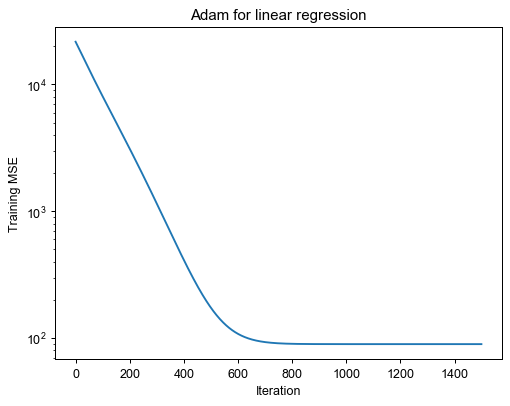

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
X, y = make_regression(n_samples=600, n_features=8, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# 增加常数列，让最后一个参数表示截距。
A = np.column_stack([X_train, np.ones(len(X_train))])
B = np.column_stack([X_test, np.ones(len(X_test))])
weights = np.zeros(A.shape[1])
m = np.zeros_like(weights); v = np.zeros_like(weights)
beta1, beta2, learning_rate, epsilon = 0.9, 0.999, 0.3, 1e-8
train_losses = []
for step in range(1, 1501):
    residual = A @ weights - y_train
    gradient = 2 * A.T @ residual / len(A)
    m = beta1 * m + (1 - beta1) * gradient
    v = beta2 * v + (1 - beta2) * gradient**2
    m_hat = m / (1 - beta1**step)
    v_hat = v / (1 - beta2**step)
    weights -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    train_losses.append(np.mean(residual**2))
print('测试集 MSE:', mean_squared_error(y_test, B @ weights))
print('最小二乘基准 MSE:', mean_squared_error(y_test, B @ np.linalg.lstsq(A, y_train, rcond=None)[0]))
plt.plot(train_losses); plt.yscale('log')
plt.xlabel('Iteration'); plt.ylabel('Training MSE'); plt.title('Adam for linear regression')
plt.show()

## 应用场景

Adam优化器适用于以下几类问题：

1. **深度学习模型的训练**：它常用于深度神经网络的优化，尤其是在处理大规模、高维数据集时表现出色。
2. **稀疏梯度问题**：例如自然语言处理（NLP）中的词嵌入，图像处理中的稀疏特征提取等，Adam能有效处理这种梯度更新不频繁的情况。
3. **非平稳目标函数**：目标函数会随着时间或训练进展而变化时（如强化学习中的值函数优化），Adam可以动态调整学习率，帮助模型更好地适应变化。

### Adam优化器的优缺点

#### 优点：

1. **自适应学习率**：Adam对每个参数都有独立的自适应学习率调整，使得模型训练更加灵活和高效，减少了手动调节学习率的工作。
2. **快速收敛**：结合动量法与RMSProp的优势，Adam能够加快收敛速度，尤其是在面对稀疏梯度或不规则梯度变化时。
3. **稳健性强**：偏差校正机制提高了训练初期的稳定性，防止收敛过快或陷入局部最优。
4. **适合大规模数据和网络**：在处理大规模数据集和深度神经网络时表现优秀，不需要额外的调整就能取得较好效果。

#### 缺点：

1. **可能过拟合**：由于Adam的适应性强，它可能在某些任务上表现过于灵活，容易陷入局部最优或过拟合，尤其是在数据较小或噪声较大时。
2. **有时收敛不充分**：尽管Adam收敛较快，但在某些场景下，尤其是收敛到较小学习率时，它可能无法进一步优化到全局最优解。
3. **对超参数较为敏感**：尽管Adam默认的超参数表现通常不错，但在一些特定任务上，学习率、动量衰减等超参数可能需要仔细调节。

### Adam优化器的运用前提条件

1. **深度学习任务**：适用于深度神经网络的优化，尤其是大规模数据集或复杂神经网络结构（如卷积神经网络、循环神经网络）。
2. **数据规模较大**：Adam在处理大规模、高维数据集时有较好的表现。
3. **梯度稀疏性**：当模型的梯度更新不频繁（如NLP中的词嵌入、稀疏特征学习）时，Adam的自适应学习率机制能更好地应对。
4. **目标函数变化较大**：适用于不平稳的优化问题，如强化学习中的动态目标。

### 实际中的应用案例

1. **自然语言处理（NLP）**：在训练**词嵌入模型（Word2Vec、GloVe）**时，Adam常用来优化稀疏的词向量表示。由于自然语言处理中的梯度往往稀疏，Adam的自适应学习率能够更有效地处理这种情况。
2. **计算机视觉**：在**卷积神经网络（CNN）**的训练中，Adam被广泛用于图像分类、物体检测等任务，尤其是在处理大规模的图像数据集（如ImageNet）时表现优异。Adam的快速收敛特性让训练大规模网络的时间显著减少。
3. **强化学习（Reinforcement Learning）**：在强化学习中，Adam常用于优化**值函数（Value Function）或策略网络**。因为强化学习的目标函数往往不平稳，Adam的自适应性可以帮助模型适应目标函数的变化，提升模型的表现。
4. **生成对抗网络（GAN）**：在训练**生成对抗网络（GAN）**时，Adam优化器通常用来更新生成器和判别器的参数。GAN的损失函数通常不稳定且梯度变化较大，Adam可以有效缓解训练过程中的不稳定性，加速收敛。

Adam优化器是深度学习中非常重要且常用的优化算法，适用于稀疏梯度、非平稳目标函数以及大规模神经网络等场景。通过自适应学习率的机制，它能够提升训练效率，并在多种任务上表现出色。